# 02 — Fire Data Proof of Concept

This notebook performs an initial proof of concept (PoC) for the fire detection data across Kalimantan and Sumatra.

Objectives:
- Load NASA FIRMS VIIRS-SNPP fire detection data
- Inspect the fire detection structure and quality
- Compare fire detection characteristics between Kalimantan and Sumatra
- Visualize the spatial distribution of detections
- Aggregate fire detections into daily fire activity
- Summarize fire detection counts and Fire Radiative Power (FRP)

This PoC is conducted across both study regions before proceeding to the full spatial binning and feature engineering pipeline.

> Note: FIRMS detections represent observed satellite thermal anomalies. A detection is not necessarily a confirmed wildfire, and the absence of a detection does not necessarily indicate the absence of fire.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
REGIONS = {
    "Kalimantan": Path("../data/raw/kalimantan/fire_firms/hourly"),
    "Sumatra": Path("../data/raw/sumatra/fire_firms/hourly")
}

fire_data = {}

for region, data_dir in REGIONS.items():
    files = sorted(data_dir.glob("*.csv"))
    
    dfs = []
    
    for file in files:
        df = pd.read_csv(file)
        
        if len(df) > 0:
            dfs.append(df)
    
    fire = pd.concat(dfs, ignore_index=True)
    fire["time_utc"] = pd.to_datetime(fire["time_utc"])
    fire["region"] = region
    
    fire_data[region] = fire
    
    print(f"{region}:")
    print(f"  Files       : {len(files)}")
    print(f"  Detections  : {len(fire):,}")
    print(f"  Date range  : {fire['time_utc'].min().date()} → {fire['time_utc'].max().date()}")
    print()

Kalimantan:
  Files       : 134
  Detections  : 146,314
  Date range  : 2026-05-01 → 2026-09-11

Sumatra:
  Files       : 5
  Detections  : 3,546
  Date range  : 2026-09-07 → 2026-09-11



In [9]:
fire_all = pd.concat(
    fire_data.values(),
    ignore_index=True
)

print("Combined shape:", fire_all.shape)
display(fire_all.head())

Combined shape: (149860, 5)


,time_utc,lat,lon,frp,region
0,2026-05-01 06:00:00,-0.24059,116.94825,4.15,Kalimantan
1,2026-05-01 06:00:00,-0.10568,117.44133,4.40,Kalimantan
2,2026-05-01 06:00:00,-0.10557,117.44176,4.07,Kalimantan
3,2026-05-01 06:00:00,-0.05591,117.27164,5.60,Kalimantan
4,2026-05-01 06:00:00,0.59490,116.66753,4.49,Kalimantan


In [10]:
summary = (
    fire_all
    .groupby("region")
    .agg(
        detections=("frp", "size"),
        frp_total=("frp", "sum"),
        frp_mean=("frp", "mean"),
        frp_max=("frp", "max")
    )
    .reset_index()
)

summary

,region,detections,frp_total,frp_mean,frp_max
0,Kalimantan,146314,1190195.58,8.134530,569.39
1,Sumatra,3546,21987.52,6.200654,132.35


## Spatial Distribution of Fire Detections

The following visualization shows the geographic distribution of observed VIIRS-SNPP fire detections across the Kalimantan study area.

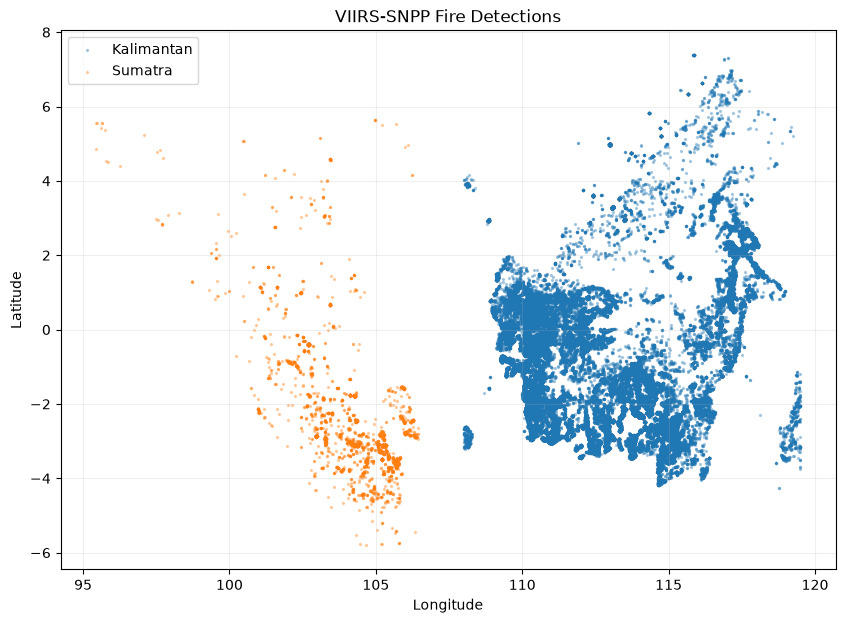

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

for region, df in fire_data.items():
    ax.scatter(
        df["lon"],
        df["lat"],
        s=2,
        alpha=0.3,
        label=region
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("VIIRS-SNPP Fire Detections")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

In [12]:
fire_all["date"] = fire_all["time_utc"].dt.date

daily_fire = (
    fire_all
    .groupby(["date", "region"])
    .agg(
        fire_count=("frp", "size"),
        frp_sum=("frp", "sum"),
        frp_mean=("frp", "mean")
    )
    .reset_index()
)

display(daily_fire.head())

,date,region,fire_count,frp_sum,frp_mean
0,2026-05-01,Kalimantan,77,460.31,5.978052
1,2026-05-02,Kalimantan,136,909.03,6.684044
2,2026-05-03,Kalimantan,112,523.04,4.670000
3,2026-05-04,Kalimantan,69,257.66,3.734203
4,2026-05-05,Kalimantan,69,229.59,3.327391


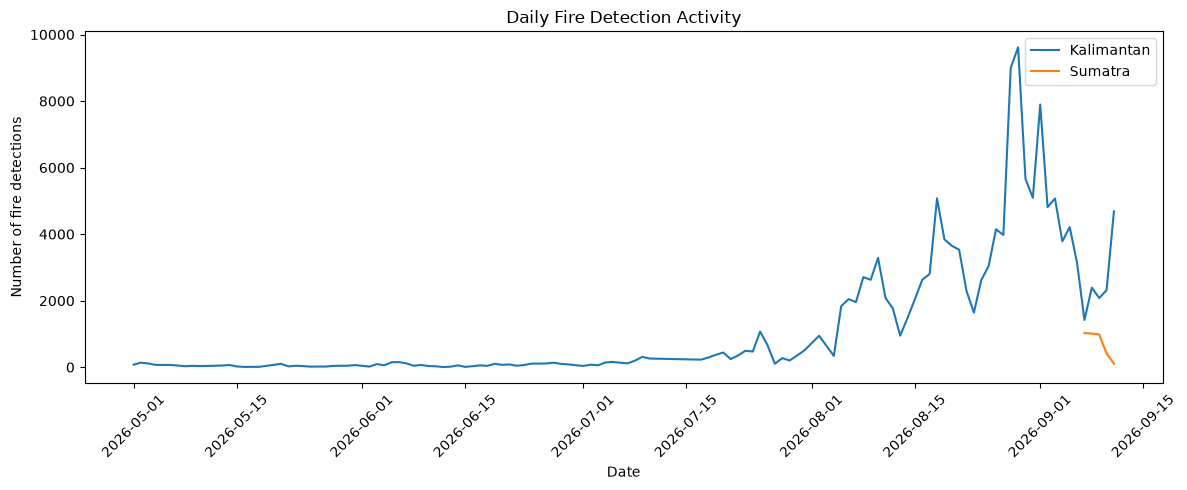

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

for region in daily_fire["region"].unique():
    subset = daily_fire[daily_fire["region"] == region]
    
    ax.plot(
        subset["date"],
        subset["fire_count"],
        label=region
    )

ax.set_xlabel("Date")
ax.set_ylabel("Number of fire detections")
ax.set_title("Daily Fire Detection Activity")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PoC Summary

The fire detection data from both Kalimantan and Sumatra were successfully loaded and inspected.

The PoC confirms that:

- Fire detection files from both study regions can be loaded successfully.
- The datasets contain spatial coordinates, timestamps, and Fire Radiative Power (FRP).
- Fire detections exhibit spatial and temporal variation across the two regions.
- Daily fire activity can be derived from the raw satellite detections.
- The fire data are suitable for the next stage of spatial binning and cell-day aggregation.

The next notebook performs spatial binning of individual fire detections into the study grid for both Kalimantan and Sumatra.